### Quadratic Equation 
#### d =   b^2 - 4ac
- if d > 0:
        2 real roots

        calculation formula: 

        r1 = (-b + sqrt(d))/2a
                            
        r2 = (-b-sqrt(d))/2a


- if d = 0:
        1 repeated root 

        calculation formula: (-b)/2a 

- if d < 0:
        No roots

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [32]:
class QuadraticState(TypedDict):
    a: float
    b: float
    c: float
    equation: str
    discriminant: float
    root1: float
    root2: float
    root: float
    nature_of_roots: Literal["real and distinct", "real and equal", "complex"]


In [33]:
def show_equation(state: QuadraticState) -> QuadraticState:
    a = state['a']
    b = state['b']
    c = state['c']
    equation = f"({a})x^2 + ({b})x + ({c}) = 0"
    return {"equation": equation}

In [34]:
def calculate_discriminant(state: QuadraticState) -> QuadraticState:
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {"discriminant": discriminant}

In [35]:
def real_roots(state: QuadraticState) -> QuadraticState:
    b = state['b']
    discriminant = state['discriminant']
    a = state['a']
    root1 = (-b + discriminant)**0.5/(2*a)
    root2 = (-b - discriminant)**0.5/(2*a)
    return {"nature_of_roots": "real and distinct", "root1": root1, "root2": root2}

In [36]:
def equal_roots(state: QuadraticState) -> QuadraticState:
    b = state['b']
    a = state['a']
    root = -b/(2*a)
    return {"nature_of_roots": "real and equal", "root": root}

In [37]:
def complex_roots(state: QuadraticState) -> QuadraticState:
    return {"nature_of_roots": "complex"}

In [38]:
def check_condition(state: QuadraticState) -> Literal["real_roots", "equal_roots", "complex_roots"]:
    discriminant = state['discriminant']
    if discriminant > 0:
        return "real_roots"
    elif discriminant == 0:
        return "equal_roots"
    else:
        return "complex_roots"

In [39]:
graph = StateGraph(QuadraticState)

#add node
graph.add_node("show_eqn", show_equation)
graph.add_node("calc_disc", calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('equal_roots', equal_roots)
graph.add_node('complex_roots', complex_roots)

#add edges
graph.add_edge(START, "show_eqn")
graph.add_edge("show_eqn", "calc_disc")
graph.add_conditional_edges("calc_disc", check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("equal_roots", END)
graph.add_edge("complex_roots", END)

workflow = graph.compile()

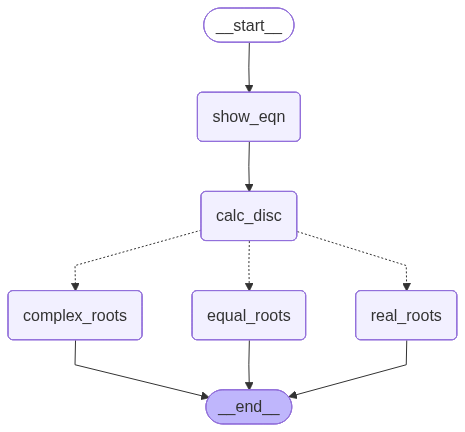

In [40]:
workflow

In [41]:
initial_state = {
    "a": 1,
    "b": -3,
    "c": 2,
}

final_state = workflow.invoke(initial_state)

print("equation:", final_state['equation'])
print("discriminant:", final_state['discriminant'])
print("nature of roots:", final_state['nature_of_roots'])
if final_state['nature_of_roots'] == "real and distinct":
    print("root1:", final_state['root1'])
    print("root2:", final_state['root2'])
elif final_state['nature_of_roots'] == "real and equal":
    print("root:", final_state['root'])
else:
    print("The roots are complex and cannot be displayed in this format.")

equation: (1)x^2 + (-3)x + (2) = 0
discriminant: 1
nature of roots: real and distinct
root1: 1.0
root2: 0.7071067811865476
